In [51]:
# standardowe biblioteki
import os, sys, time, glob, random, base64, shutil, pathlib, io, json
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

# Colab wyświetlanie
from IPython.display import Javascript, display, Audio, Image as DImage
from google.colab.output import eval_js

# TensorFlow/Keras
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mnv2_preprocess
from tensorflow.keras.models import load_model
print("TF:", tf.__version__)



TF: 2.20.0


In [52]:
BASE_DIR='/content/projekt_kpn'
RAW_DIR= BASE_DIR + '/raw'
DATA_DIR= BASE_DIR + '/data'

KATEGORIE= ['Kamień', 'Papier', 'Nożyce']
IMG_SIZE= (224, 224)
TRAIN_RATIO= 0.8

In [53]:
for k in KATEGORIE:
  os.makedirs(os.path.join(RAW_DIR, k), exist_ok= True)

In [54]:
def zbierz_proby(kategoria, ile_min=20, jakosc=0.9, lustrzane=True):
    # proste GUI w JS: przycisk "Zrób zdjęcie" i "Zakończ"
    target = os.path.join(RAW_DIR, kategoria)
    os.makedirs(target, exist_ok=True)

    js = Javascript('''
      async function sesja(nMin, q) {
        const div = document.createElement('div');
        const btn = document.createElement('button');
        btn.textContent = 'Zrób zdjęcie';
        btn.style.fontSize = '16px';
        btn.style.marginRight = '8px';
        const done = document.createElement('button');
        done.textContent = 'Zakończ';
        done.disabled = true;
        const info = document.createElement('span');
        info.style.marginLeft = '10px';
        info.textContent = '0 / ' + nMin;

        div.appendChild(btn);
        div.appendChild(done);
        div.appendChild(info);

        const video = document.createElement('video');
        video.style.display = 'block';
        video.style.maxWidth = '480px';
        const stream = await navigator.mediaDevices.getUserMedia({video:true});
        document.body.appendChild(div);
        div.appendChild(video);
        video.srcObject = stream;
        await video.play();
        google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

        const images = [];
        btn.onclick = () => {
          const canvas = document.createElement('canvas');
          canvas.width = video.videoWidth;
          canvas.height = video.videoHeight;
          canvas.getContext('2d').drawImage(video, 0, 0);
          images.push(canvas.toDataURL('image/jpeg', q));
          info.textContent = images.length + ' / ' + nMin;
          if (images.length >= nMin) done.disabled = false;
        };

        await new Promise(resolve => done.onclick = resolve);
        stream.getTracks().forEach(t => t.stop());
        div.remove();
        return images;
      }
    ''')
    display(js)
    data_urls = eval_js(f"sesja({ile_min}, {jakosc})")


    zapisane = 0
    for i, d in enumerate(data_urls):
        raw = base64.b64decode(d.split(',')[1])
        fname = os.path.join(target, f"{kategoria}_{int(time.time()*1000)}_{i:03d}.jpg")
        with open(fname, 'wb') as f:
            f.write(raw)
        zapisane += 1

        if lustrzane:
            img = Image.open(io.BytesIO(raw)).convert('RGB')
            img = ImageOps.mirror(img)
            fname2 = os.path.join(target, f"{kategoria}_{int(time.time()*1000)}_{i:03d}_m.jpg")
            img.save(fname2, "JPEG", quality=int(jakosc*100))
            zapisane += 1

    print("Zapisano:", zapisane, "plików do", target)


In [55]:
# zbierz_proby('Papier', ile_min=50)

In [56]:
# zbierz_proby('Kamień', ile_min=50)

In [57]:
# zbierz_proby('Norzyce', ile_min=50)

In [58]:
def podziel_train_test():
    if os.path.exists(DATA_DIR):
        shutil.rmtree(DATA_DIR)
    for split in ["train", "test"]:
        for k in KATEGORIE:
            os.makedirs(os.path.join(DATA_DIR, split, k), exist_ok=True)

    for k in KATEGORIE:
        pliki = glob.glob(os.path.join(RAW_DIR, k, "*"))
        pliki = [p for p in pliki if os.path.isfile(p)]
        random.shuffle(pliki)
        n = len(pliki)
        n_train = int(n * TRAIN_RATIO)
        train_files = pliki[:n_train]
        test_files  = pliki[n_train:]
        for src in train_files:
            shutil.copy2(src, os.path.join(DATA_DIR, "train", k, os.path.basename(src)))
        for src in test_files:
            shutil.copy2(src, os.path.join(DATA_DIR, "test", k, os.path.basename(src)))
    print("Dane w", DATA_DIR)

In [59]:
podziel_train_test()

Dane w /content/projekt_kpn/data


In [60]:
AUTOTUNE = tf.data.AUTOTUNE
BATCH_SIZE = 32

def wczytaj_dane():
  train_ds= image_dataset_from_directory(
      os.path.join(DATA_DIR, 'train'),
      image_size=IMG_SIZE,
      batch_size=BATCH_SIZE,
      label_mode='categorical',
      shuffle=True
  )
  test_ds= image_dataset_from_directory(
      os.path.join(DATA_DIR, 'test'),
      image_size=IMG_SIZE,
      batch_size=BATCH_SIZE,
      label_mode='categorical',
      shuffle=False
  )

  return train_ds.prefetch(AUTOTUNE), test_ds.prefetch(AUTOTUNE), train_ds.class_names

In [61]:
def zbuduj_model(n_klas):
  wej= layers.Input( shape = IMG_SIZE + (3,))
  x = layers.RandomFlip('horizontal')(wej)
  x= layers.RandomRotation(0.05)(x)
  x= layers.RandomZoom(0.1)(x)
  x= mnv2_preprocess(x)

  baza= MobileNetV2(include_top=False, input_tensor=x, weights='imagenet', pooling='avg')
  baza.trainable= False

  x= layers.Dropout(0.2)(baza.output)
  wyj= layers.Dense(n_klas, activation='softmax')(x)
  model= models.Model(wej, wyj)
  model.compile(
      optimizer='adam',
      loss='categorical_crossentropy',
      metrics=['accuracy']
  )

  return model


Found 166 files belonging to 3 classes.
Found 42 files belonging to 3 classes.


/tmp/ipykernel_4659/790922569.py:8: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  baza= MobileNetV2(include_top=False, input_tensor=x, weights='imagenet', pooling='avg')


Epoch 1/6
6/6 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.5301 - loss: 0.8540 - val_accuracy: 0.5476 - val_loss: 0.7086
Epoch 2/6
6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.5964 - loss: 0.7280 - val_accuracy: 0.7143 - val_loss: 0.5802
Epoch 3/6
6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.6807 - loss: 0.6158 - val_accuracy: 0.6905 - val_loss: 0.5491
Epoch 4/6
6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.7229 - loss: 0.5488 - val_accuracy: 0.8095 - val_loss: 0.4528
Epoch 5/6
6/6 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.7771 - loss: 0.4653 - val_accuracy: 0.7619 - val_loss: 0.4651
Epoch 6/6
6/6 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.7711 - loss: 0.4397 - val_accuracy: 0.8571 - val_loss: 0.3684
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 340ms/step - accuracy: 0.8571 - loss: 0.3684
Test acc: acc


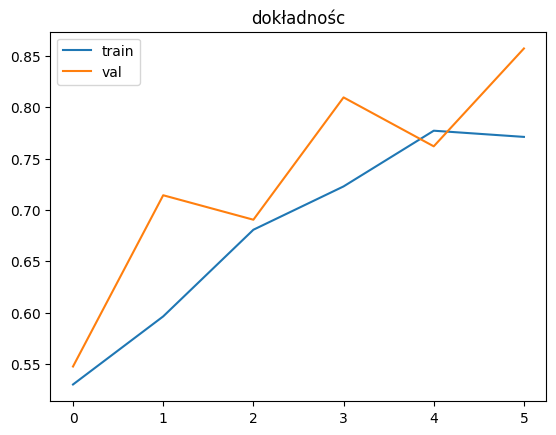

In [62]:
train_ds, test_ds, class_names= wczytaj_dane()


model= zbuduj_model(len(class_names))
hist= model.fit(train_ds, validation_data = test_ds, epochs= 6)
loss, acc= model.evaluate(test_ds)

print('Test acc: acc')

plt.plot(hist.history['accuracy'], label='train')
plt.plot(hist.history['val_accuracy'], label='val')
plt.legend()
plt.title('dokładnośc')
plt.show()